# 03 · Stitching GTFS-Pathways to the ほこナビ network

Step 1.4, exploration only. Logic is in `importer/analysis/stitch.py`.

Question: can each Pathways node (entrance, generic node, boarding area) be matched to a ほこナビ node on the same level and within a small distance, and do the pathways line up with ほこナビ links?

Both layers are projected to EPSG:6677 (metres). Matching is one-to-one per level (assignment problem), capped at a maximum distance. CLAUDE.md does not spell out the matching rule beyond "by level and distance"; this notebook tests it.

In [1]:
import pandas as pd
from importer.analysis.stitch import *

pd.set_option('display.width', 250, 'display.max_columns', 40)
feed = P.load_feed()
len(STATION_SLUGS)

12

## 1. Node matching at several distance caps

`median / max nearest` is the distance from each Pathways node to the closest ほこナビ node on the same level, before any one-to-one assignment.

In [2]:
mt = match_table(feed)
mt

,station,pathways nodes,hokonavi nodes,median nearest m,max nearest m,matched <= 0.25 m,matched <= 1 m,matched <= 5 m,matched <= 10 m
0,shinjuku-nishiguchi,209,225,0.04,0.07,209,209,209,209
1,higashi-shinjuku,97,110,0.04,0.06,97,97,97,97
2,ueno-okachimachi,237,247,0.04,0.07,237,237,237,237
3,daimon,326,340,0.04,0.07,326,326,326,326
4,akabanebashi,121,124,0.04,0.07,121,121,121,121
5,azabu-juban,200,211,0.04,0.07,200,200,200,200
6,roppongi,249,267,0.04,0.07,249,249,249,249
7,aoyama-itchome,250,271,0.04,0.07,250,250,250,250
8,kokuritsu-kyogijo,282,301,0.04,0.07,282,282,282,282
9,yoyogi,127,138,0.04,0.07,127,127,127,127


At 10 of 12 stations every Pathways node has a ほこナビ node within 7 cm on the same level, so the Pathways nodes were evidently derived from the ほこナビ nodes. The 7 cm is the datum difference (JGD2011 vs WGS84), not a matching error. Because of that the threshold hardly matters: anything from 0.25 m to 10 m gives the same result at those stations. 新宿 and 都庁前 are the exceptions.

## 2. Do the pathways line up with ほこナビ links?

With a 1 m cap. A pathway is OK when both endpoints are matched, a ほこナビ link joins them, and the modes agree (stairs-stairs, escalator-escalator, elevator-elevator, walkway with flat/slope/moving walkway/unknown).

In [3]:
et = edge_table(feed)
et

,station,pathways,"link found, mode agrees","link found, mode differs",no direct link,endpoint unmatched,links without pathway,hokonavi nodes unmatched,pathways nodes unmatched
0,shinjuku-nishiguchi,238,238,0,0,0,16,16,0
1,higashi-shinjuku,107,107,0,0,0,13,13,0
2,ueno-okachimachi,257,257,0,0,0,10,10,0
3,daimon,364,364,0,0,0,14,14,0
4,akabanebashi,134,134,0,0,0,3,3,0
5,azabu-juban,224,224,0,0,0,11,11,0
6,roppongi,280,280,0,0,0,18,18,0
7,aoyama-itchome,273,272,0,1,0,23,21,0
8,kokuritsu-kyogijo,314,313,1,0,0,19,19,0
9,yoyogi,143,143,0,0,0,11,11,0


## 3. 新宿: where the two layers disagree

No constant offset explains it: unmatched Pathways nodes are 4 to 50 m from the nearest unmatched ほこナビ node.

pathways nodes unmatched by level: {-2.5: 13, -2.0: 36, -1.0: 10}
hokonavi nodes unmatched by level: {-3.0: 3, -2.0: 16, -1.0: 52, -0.5: 10, 0.0: 3, 1.0: 2}
hokonavi links without a pathway, by route_type: {'no specific type': 72, 'escalator': 15, 'stairs': 9, 'elevator': 4}


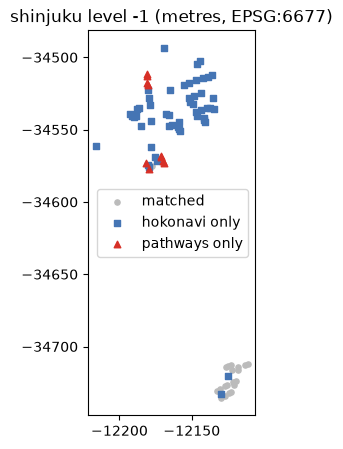

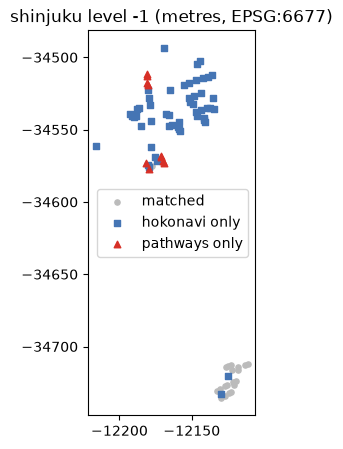

In [4]:
s = stitch_station(feed, '428')
print('pathways nodes unmatched by level:', s.pw[s.pw.stop_id.isin(s.unmatched_pw)].level.value_counts().sort_index().to_dict())
print('hokonavi nodes unmatched by level:', s.hk[s.hk.node_id.isin(s.unmatched_hk)].level.value_counts().sort_index().to_dict())
x = s.links_without_pathway
print('hokonavi links without a pathway, by route_type:', x.route_type.map(H.ROUTE_TYPE).value_counts().to_dict())
plot_unmatched(s, -1.0)

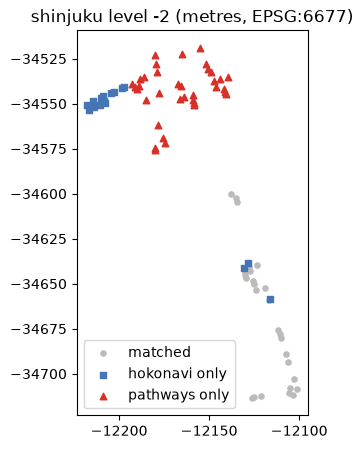

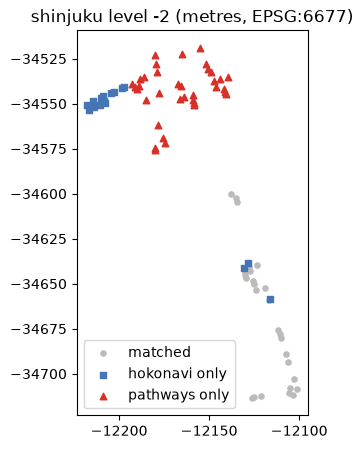

In [5]:
plot_unmatched(s, -2.0)

## 4. Other exceptions

Pathways that have no direct ほこナビ link, or a different mode, and the nodes that stay unmatched at 1 m.

In [6]:
rows = []
for sid in ('429', '425', '426'):
    t = stitch_station(feed, sid)
    rows.append({'station': t.slug, 'no direct link': t.edge_no_link, 'mode differs': t.edge_mode_mismatch, 'pathways nodes unmatched': t.unmatched_pw})
pd.DataFrame(rows)

,station,no direct link,mode differs,pathways nodes unmatched
0,tochomae,"[429L0008, 429L0009, 429L0037, 429L0038]",[],"[429N0009, 429N0069]"
1,aoyama-itchome,[425L0136],[],[]
2,kokuritsu-kyogijo,[],[426L0284],[]


In [7]:
t = stitch_station(feed, '429')
near = nearest_same_level(t.pw, t.hk)
t.pw.assign(nearest_m=near).sort_values('nearest_m').tail(3)[['stop_id', 'level', 'nearest_m']]

,stop_id,level,nearest_m
2542,429N0063,-2.0,0.068838
2488,429N0009,-2.0,0.958286
2546,429N0069,-2.0,3.535443


## 5. ほこナビ-only nodes and links

At the 10 clean stations, how many ほこナビ links have no pathway, and what are they?

In [8]:
rows = []
for sid, slug in STATION_SLUGS.items():
    if sid in ('428',):
        continue
    t = stitch_station(feed, sid)
    x = t.links_without_pathway
    hk = t.hk[t.hk.node_id.isin(t.unmatched_hk)]
    rows.append({'station': slug, 'links without pathway': len(x), 'by type': x.route_type.map(H.ROUTE_TYPE).value_counts().to_dict(), 'rank': x['rank'].value_counts().to_dict(), 'unmatched hk nodes': len(hk), 'on floors': sorted(set(hk.level))})
pd.DataFrame(rows)

,station,links without pathway,by type,rank,unmatched hk nodes,on floors
0,shinjuku-nishiguchi,16,{'no specific type': 16},"{'SSS': 15, 'ASS': 1}",16,"[-3.0, -1.0, -0.5, -0.2, 0.0, 1.0]"
1,higashi-shinjuku,13,{'no specific type': 13},{'SSS': 13},13,[-2.0]
2,ueno-okachimachi,10,"{'no specific type': 8, 'stairs': 2}","{'SSS': 6, 'AZZ': 2, 'CSS': 2}",10,"[-1.0, -0.5]"
3,daimon,14,"{'no specific type': 12, 'slope': 1, 'elevator...","{'SSS': 8, 'CSS': 5, 'AAS': 1}",14,"[-3.0, -1.0, 0.0]"
4,akabanebashi,3,{'no specific type': 3},{'SSS': 3},3,"[-2.0, -1.0]"
5,azabu-juban,11,"{'no specific type': 9, 'stairs': 2}","{'SSS': 5, 'ASS': 4, 'AZZ': 2}",11,"[-4.0, -1.0, -0.5, 0.0]"
6,roppongi,18,{'no specific type': 18},{'SSS': 18},18,"[-7.0, -5.0, -1.0]"
7,aoyama-itchome,23,"{'no specific type': 19, 'escalator': 2, 'stai...","{'SSS': 14, 'ASS': 5, 'CSS': 2, 'SSZ': 2}",21,"[-4.0, -1.5, -1.0, -0.5]"
8,kokuritsu-kyogijo,19,"{'no specific type': 17, 'slope': 2}","{'SSS': 15, 'ASS': 2, 'AAS': 2}",19,"[-2.0, -1.0]"
9,yoyogi,11,{'no specific type': 11},{'SSS': 11},11,[-1.0]
